In [2]:
%matplotlib inline
import torch
import d2l.torch as d2l
from torch import nn

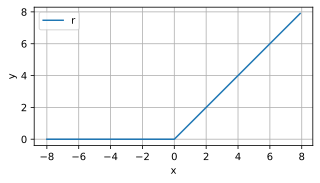

In [2]:
#ReLU Activation Function
x = torch.arange(-8.0, 8.0, 0.1, requires_grad=True)
y = torch.relu(x)

d2l.plot(x.detach(), y.detach(), 'x', 'y', 'relu', figsize=(5, 2.5))

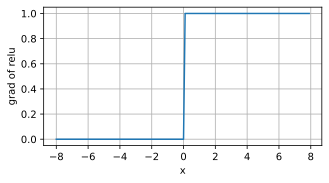

In [3]:
y.backward(torch.ones_like(x))
d2l.plot(x.detach(), x.grad, 'x', 'grad of relu', figsize=(5, 2.5))

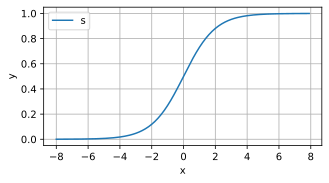

In [4]:
#Sigmoid Activation Function
x = torch.arange(-8.0, 8.0, 0.1, requires_grad=True)
y = torch.sigmoid(x)

d2l.plot(x.detach(), y.detach(), 'x', 'y', 'sigmoid', figsize=(5, 2.5))

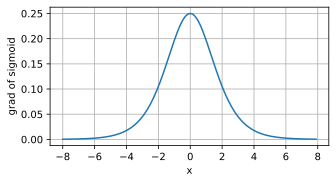

In [5]:
y.backward(torch.ones_like(x))
d2l.plot(x.detach(), x.grad, 'x', 'grad of sigmoid', figsize=(5, 2.5))

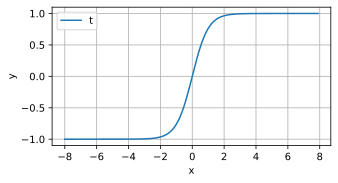

In [6]:
#Hyperbolic tangent
x = torch.arange(-8.0, 8.0, 0.1, requires_grad=True)
y = torch.tanh(x)

d2l.plot(x.detach(), y.detach(), 'x', 'y', 'tanh', figsize=(5, 2.5))

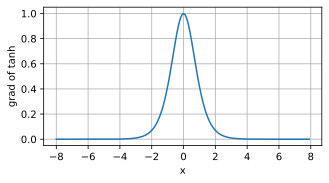

In [7]:
y.backward(torch.ones_like(x))
d2l.plot(x.detach(), x.grad, 'x', 'grad of tanh', figsize=(5, 2.5))

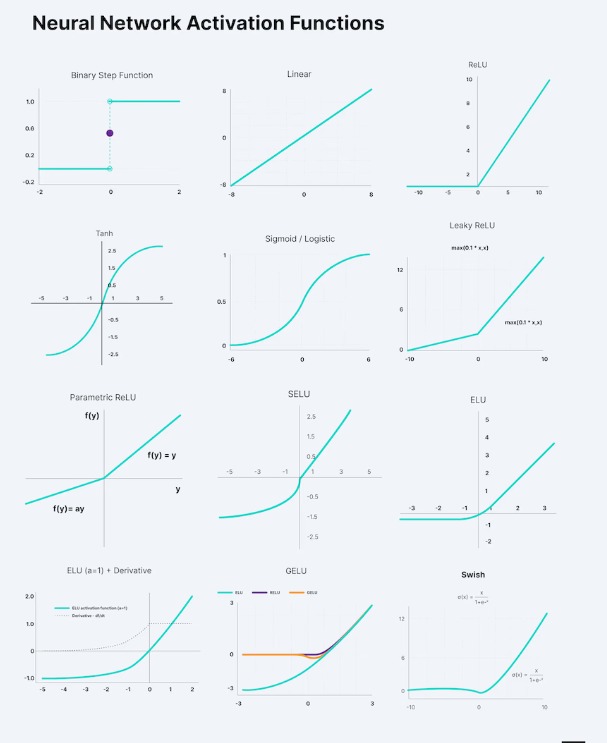

In [8]:
#Implementation of MLP from scratch

#When a tensor is wrapped with torch.nn.Parameter, it automatically becomes a part of the model's parameters, 
# and thus it will be updated when backpropagation is applied during training. 
#This is fundamental because it tells PyTorch's optimizer which tensors should be updated through learning processes.

class MLPScratch(d2l.Classifier):
    def __init__(self, num_inputs, num_outputs, num_hiddens, lr, sigma=0.01):
        super().__init__()
        self.save_hyperparameters()
        self.W1 = nn.Parameter(torch.randn(num_inputs, num_hiddens) * sigma)
        self.b1 = nn.Parameter(torch.zeros(num_hiddens))
        self.W2 = nn.Parameter(torch.randn(num_hiddens, num_outputs) * sigma)
        self.b2 = nn.Parameter(torch.zeros(num_outputs))

def relu(X):
    return torch.max(X, torch.zeros_like(X))

@d2l.add_to_class(MLPScratch)
def forward(self, X):
    X = X.reshape(-1, self.num_inputs)
    H = relu(torch.matmul(X, self.W1) + self.b1)
    return torch.matmul(H, self.W2) + self.b2

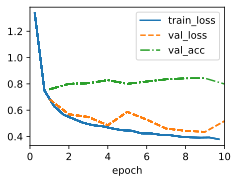

In [9]:
model = MLPScratch(num_inputs=784, num_outputs=10, num_hiddens=256, lr=0.1)
data = d2l.FashionMNIST(batch_size=256)
trainer = d2l.Trainer(max_epochs=10)
trainer.fit(model, data)

In [19]:
class MLP(d2l.Classifier):
    def __init__(self, num_outputs, num_hidden, lr):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.LazyLinear(num_hidden),
            nn.ReLU(),
            nn.LazyLinear(num_outputs)
        )


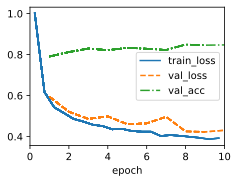

In [20]:
model = MLP(num_outputs=10, num_hidden=256, lr=0.1)
data = d2l.FashionMNIST(batch_size=256)
trainer = d2l.Trainer(max_epochs=10)
trainer.fit(model, data)

In [16]:
#print weights
print(model.net[3].weight.data)

tensor([[ 0.0318, -0.0060,  0.0382,  ..., -0.0746, -0.0178, -0.0446],
        [ 0.0260,  0.0386, -0.0422,  ..., -0.0566, -0.0199,  0.0478],
        [-0.0562, -0.0294, -0.0021,  ..., -0.0676,  0.0536, -0.0094],
        ...,
        [ 0.0812,  0.0430,  0.0566,  ..., -0.0030, -0.0057, -0.0185],
        [ 0.0161, -0.0206, -0.0237,  ..., -0.0051,  0.0167, -0.0416],
        [ 0.0328,  0.0297, -0.0485,  ...,  0.0222, -0.0464,  0.0276]])


#### Hidden units = 256
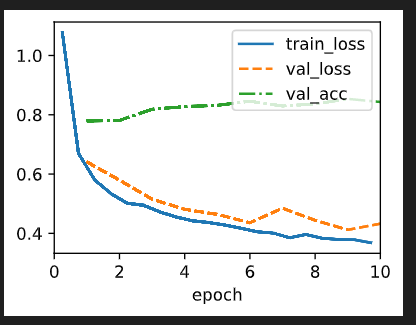

#### Hidden units = 128
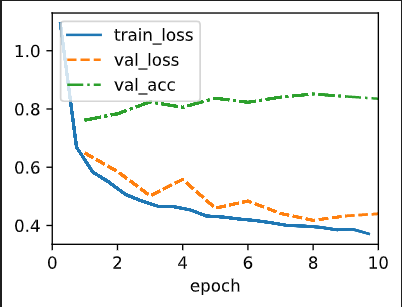

#### Hidden units = 64
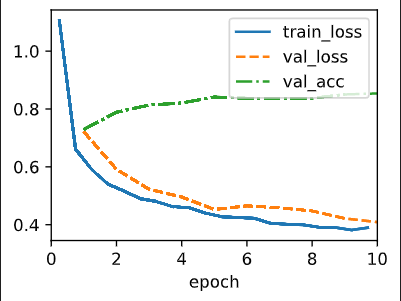

#### Hidden units = 32
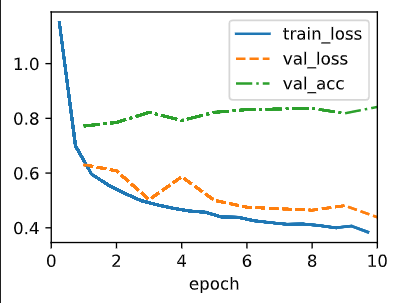

#### Hidden units = 4  Error increased and validation accuracy decreased to around 0.75
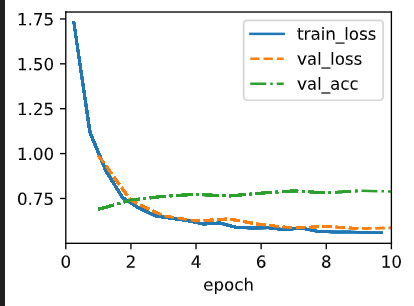

#### Hidden units = 1 The network almost stopped learning. High training/validation error and low validation accuracy. 
#### This indicates underfitting
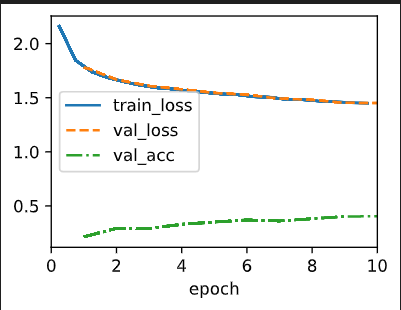

#### Hidden layers = 2  & Hidden units = 256
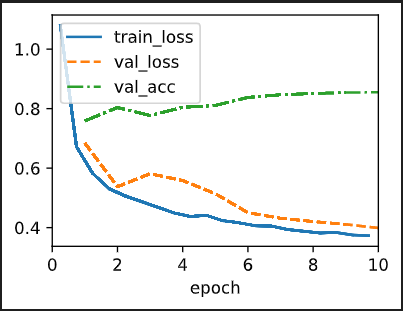 

#### Hidden layers = 2 & Hidden units = 64. This achieved slightly higher accuracy than model with one hidden layer.
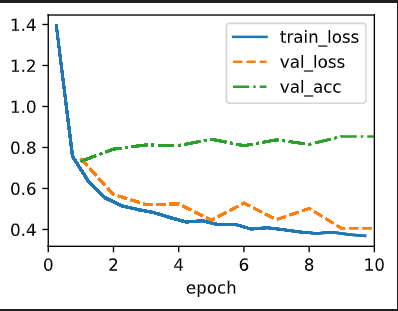

#### Hidden layers = 2 & Hidden units = 4.
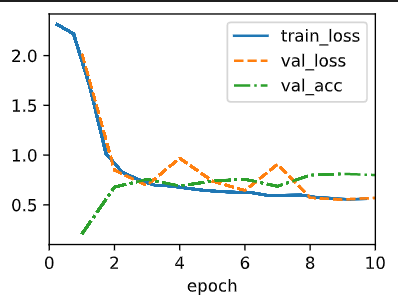

#### Hidden layers = 2 & Hidden units = 1
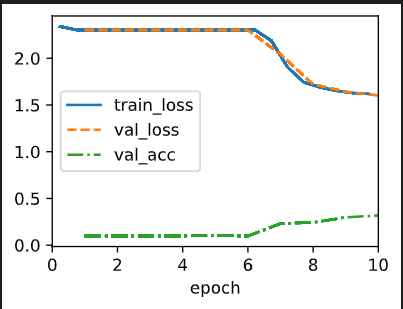

#### Hidden layer = 1 & Hidden units = 256 & Learning rate = 0.25
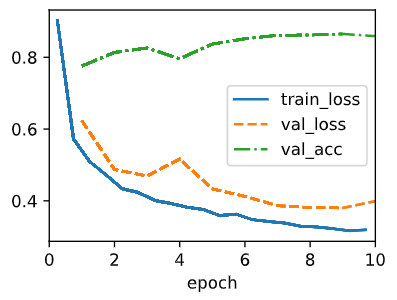

#### Hidden layer = 1 & Hidden units = 256 & Learning rate = 0.5. This resulted in unstable learning as there are high spikes
#### in validation loss and large gap between training loss and validation loss indicating poor generalization.
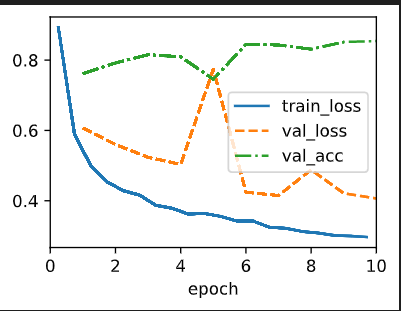

#### Hidden layer = 1 & Hidden units = 256 & Learning rate = 0.75. High training/validation error and low validation accuracy.
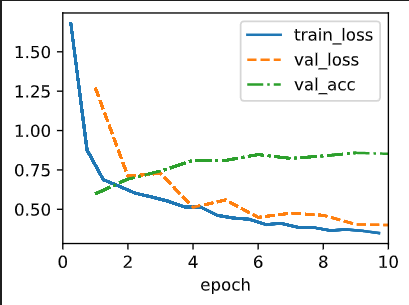

#### Hidden layer = 1 & Hidden units = 256 & Learning rate = 1. Very high raining/validation error and very low validation accuracy.
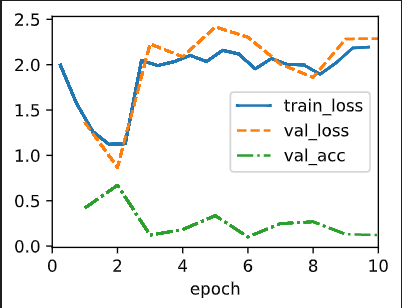   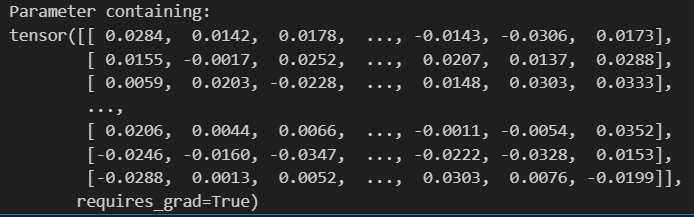

#### Hidden layer = 1 & Hidden units = 256 & Learning rate = 0.5 & Epochs = 20. 
#### Many spikes in validation error
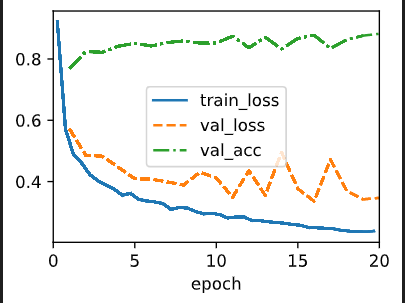


#### Hidden layer = 1 & Hidden units = 256 & Learning rate = 0.75 & Epochs = 20. 
#### Model was able to achieve high accuracy with higher learning rate but required more epochs
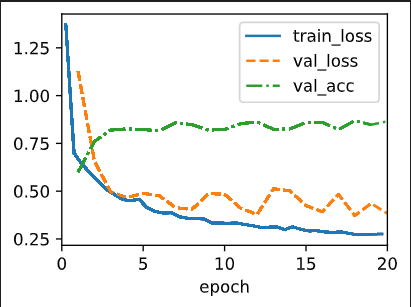

139.72 sec


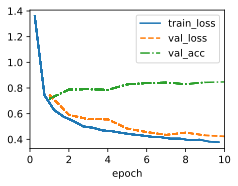

In [36]:
# Compare the speed of MLPScratch and MLP
import time

start = time.time()
model = MLPScratch(num_inputs=784, num_outputs=10, num_hiddens=256, lr=0.1)
data = d2l.FashionMNIST(batch_size=256)
trainer = d2l.Trainer(max_epochs=10)
trainer.fit(model, data)
print(f'{time.time() - start:.2f} sec')

172.42 sec


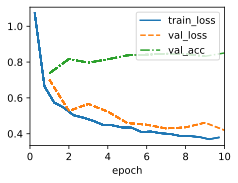

In [39]:
start = time.time()
model = MLP(num_outputs=10, num_hidden=256, lr=0.1)
data = d2l.FashionMNIST(batch_size=256)
trainer = d2l.Trainer(max_epochs=10)
trainer.fit(model, data)
print(f'{time.time() - start:.2f} sec')

In [4]:
#Measuring matrix multiplication speed for tensor for well-aligned and miss-aligned matrices
import time
for dim in (1024, 1025, 1026, 1028, 1032):
    A = torch.randn(dim, dim)
    B = torch.randn(dim, dim)

    start = time.time()
    C = torch.matmul(A, B)
    print(f'dimension {dim}, time {time.time() - start:.2f} sec')
    #Switch to GPU
    if torch.cuda.is_available():
        A = A.cuda()
        B = B.cuda()
        torch.cuda.synchronize()
        start = time.time()
        C = torch.matmul(A, B)
        torch.cuda.synchronize()
        print(f'GPU dimension {dim}, time {time.time() - start:.2f} sec')

dimension 1024, time 0.04 sec
GPU dimension 1024, time 0.12 sec
dimension 1025, time 0.02 sec
GPU dimension 1025, time 0.00 sec
dimension 1026, time 0.02 sec
GPU dimension 1026, time 0.00 sec
dimension 1028, time 0.01 sec
GPU dimension 1028, time 0.00 sec
dimension 1032, time 0.02 sec
GPU dimension 1032, time 0.00 sec


#### Hidden layer = 1 & Hidden units = 256 & Learning rate = 0.1 & Epochs = 10 & activation function = sigmoid. 
#### Higher training time (around 4 minutes). This is because sigmoid function is expensive to compute than ReLU.
#### Slightly less accuracy than ReLU.
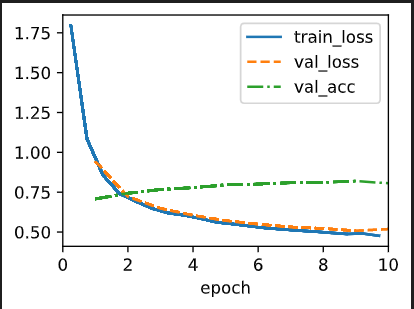

#### Hidden layer = 1 & Hidden units = 256 & Learning rate = 0.1 & Epochs = 10 & activation function = sigmoid. 
#### Higher training time (around 4 minutes). Achieved almost same accuracy as ReLU function but traning time was high with same number of epochs
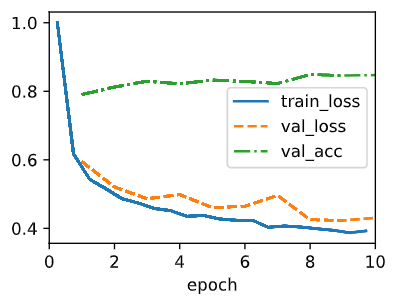